<a href="https://colab.research.google.com/github/deniwidi/data-science-2026/blob/main/Pertemuan4_Deni_Widi_Alfian_240401010340.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pertemuan ke-5

- Nama    : Deni Widi Alfian
- NIM     : 240401010340
- Kelas   : IF405

## Langkah 1: Load & Inspect Dataset
Muat dataset **Tips** menggunakan `sns.load_dataset()`. Tampilkan `shape`, `dtypes`, dan `.describe()`.

In [20]:
# ── TEMPLATE DASHBOARD VISUALISASI STATIS ────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Set style global Seaborn
sns.set_theme(style='whitegrid', palette='Set2')

# Load dataset Tips
df = sns.load_dataset('tips')

print('=== Shape ===')
print(df.shape)

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== 5 Baris Pertama ===')
print(df.head())

print('\n=== Statistik Deskriptif ===')
print(df.describe().round(2))

=== Shape ===
(244, 7)

=== Data Types ===
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

=== 5 Baris Pertama ===
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

=== Statistik Deskriptif ===
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


### 📝 Deskripsi Dataset
Dataset Tpis terdiri dari 244 baris dan 7 kolom yang merekam data tagihan di sebuah restoran.

## Langkah 2: Setup Figure Layout


/tmp/ipykernel_13439/3244508708.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df.groupby('day')['total_bill'].mean()


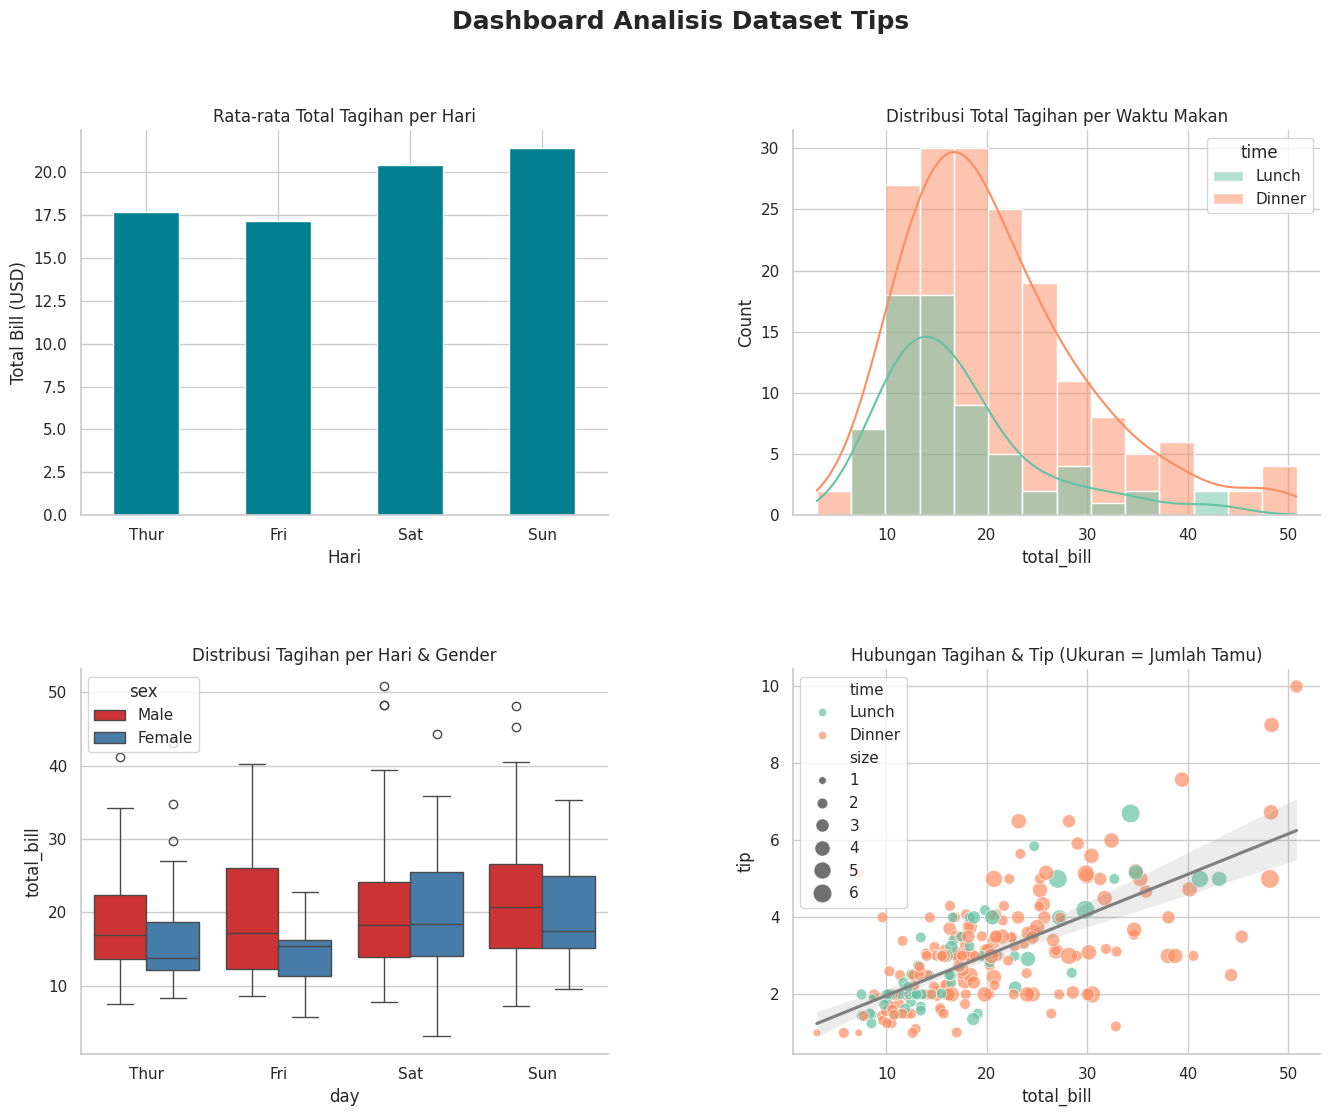

Dashboard tersimpan sebagai dashboard_tips.png


In [21]:
# === 2. SETUP FIGURE LAYOUT ===
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Tips',
            fontsize=18, fontweight='bold', y=0.98)

# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig,
                      hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0]) # kiri atas
ax2 = fig.add_subplot(gs[0, 1]) # kanan atas
ax3 = fig.add_subplot(gs[1, 0]) # kiri bawah
ax4 = fig.add_subplot(gs[1, 1]) # kanan bawah

# ========== 3. GRAFIK 1: Bar Chart ==========
avg_by_day = df.groupby('day')['total_bill'].mean()
avg_by_day.plot(kind='bar', ax=ax1, color='#028090',
                edgecolor='white')

ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari'); ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)

# ========== 4. GRAFIK 2: Histogram + KDE ==========
sns.histplot(data=df, x='total_bill', hue='time',
             kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.spines[['top','right']].set_visible(False)

# ========== 5. GRAFIK 3: Boxplot ==========
sns.boxplot(data=df, x='day', y='total_bill',
          hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.spines[['top','right']].set_visible(False)

# ========== 6. GRAFIK 4: Scatter Plot ==========
sns.scatterplot(data=df, x='total_bill', y='tip',
               hue='time', size='size', sizes=(30,180),
palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip',
            scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.spines[['top','right']].set_visible(False)

# ========== 7. EKSPOR ==========
plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_tips.png')


## Penjelasan Grafik
---

## Grafik 1 — Bar Chart: Rata-rata Total Tagihan per Hari

**What?** (Apa yang terlihat?)

Grafik batang ini menampilkan rata-rata total tagihan (USD) untuk setiap hari operasional restoran (Kamis, Jumat, Sabtu, dan Minggu) berdasarkan 244 observasi pada dataset Tips. Nilai rata-rata berkisar antara sekitar $17 di hari Jumat hingga sekitar $21 di hari Sabtu.

**So what?** (Mengapa ini penting?)

Hari Sabtu dan Minggu memiliki rata-rata tagihan tertinggi dibandingkan hari lainnya, mengindikasikan bahwa pelanggan akhir pekan cenderung memesan lebih banyak atau memilih menu yang lebih mahal.

**Now what?** (Apa tindak lanjutnya?)

Manajemen restoran sebaiknya memastikan stok bahan baku dan jumlah staf yang lebih besar di hari Sabtu dan Minggu untuk mengakomodasi permintaan yang lebih tinggi.

## Grafik 2   Histogram + KDE: Distribusi Total Tagihan per Waktu Makan

**What?** (Apa yang terlihat?)

Grafik ini menampilkan distribusi total tagihan (USD) yang dipisahkan berdasarkan waktu makan (Lunch dan Dinner) menggunakan histogram dan kurva KDE. Distribusi Dinner lebih lebar dan memiliki ekor panjang ke kanan (right-skewed), sementara Lunch lebih terkonsentrasi di nilai yang lebih rendah.

**So what?** (Mengapa ini penting?)

Pelanggan yang makan Dinner cenderung menghasilkan tagihan yang lebih bervariasi dan secara rata-rata lebih tinggi dibandingkan Lunch. Ini mengindikasikan bahwa sesi makan malam menarik kelompok pelanggan yang lebih beragam, mulai dari meja kecil hingga meja besar dengan pengeluaran signifikan. Skewness positif pada distribusi Dinner menunjukkan adanya beberapa transaksi bernilai sangat tinggi yang menarik rata-rata ke atas.

**Now what?** (Apa tindak lanjutnya?)

Restoran dapat mempertimbangkan strategi promosi khusus untuk sesi Lunch guna meningkatkan nilai tagihan rata-rata, misalnya melalui menu paket atau upselling. Untuk Dinner, perlu diteliti lebih lanjut karakteristik kelompok pelanggan dengan tagihan tertinggi untuk memaksimalkan pendapatan.

## Grafik 3 — Boxplot: Distribusi Tagihan per Hari & Gender

**What?** (Apa yang terlihat?)

Boxplot ini membandingkan distribusi total tagihan (USD) untuk setiap hari dalam seminggu, dibedakan berdasarkan gender pelanggan (Male/Female). Lima ringkasan statistik (minimum, Q1, median, Q3, dan maksimum) terlihat jelas untuk setiap kelompok.

**So what?** (Mengapa ini penting?)

Pelanggan laki-laki secara konsisten memiliki median tagihan yang lebih tinggi dibandingkan perempuan di hampir semua hari, dengan perbedaan paling mencolok di hari Sabtu. Hari Sabtu juga memiliki persebaran (IQR) terbesar, mengindikasikan variasi tagihan yang paling beragam. Outlier pada hari Sabtu dan Minggu menunjukkan adanya meja dengan pengeluaran sangat tinggi yang jauh melampaui pola umum.

**Now what?** (Apa tindak lanjutnya?)

Perlu dilakukan analisis lebih lanjut apakah perbedaan tagihan antar gender dipengaruhi oleh faktor lain seperti ukuran meja atau jenis menu. Outlier di akhir pekan layak ditelusuri lebih jauh — apakah berasal dari event khusus atau reservasi grup besar — karena berpotensi menjadi segmen pelanggan premium yang perlu dipertahankan.

## Grafik 4 — Scatter Plot: Hubungan Tagihan & Tip


**What?** (Apa yang terlihat?)
Scatter plot ini memvisualisasikan hubungan antara total tagihan (sumbu X) dan jumlah tip (sumbu Y), dengan warna membedakan waktu makan (Lunch/Dinner) dan ukuran titik mencerminkan jumlah tamu per meja. Garis regresi abu-abu menunjukkan tren keseluruhan. Total tagihan berkisar antara $3 hingga $51, sedangkan tip berkisar antara $1 hingga $10.

**So what?** (Mengapa ini penting?)
Terdapat **korelasi positif yang jelas** antara total tagihan dan jumlah tip — semakin besar tagihan, semakin besar pula tip yang diberikan. Ini adalah pola yang wajar secara logis. Titik berukuran lebih besar (meja dengan lebih banyak tamu) cenderung berada di area tagihan dan tip yang lebih tinggi, memperkuat hubungan antara ukuran meja dan total pengeluaran. Pelanggan Dinner (biru) mendominasi tagihan bernilai tinggi.

**Now what?** (Apa tindak lanjutnya?)
Restoran dapat memaksimalkan pendapatan dari tip dengan mendorong peningkatan nilai tagihan melalui strategi upselling (rekomendasi menu tambahan, dessert, atau minuman). Perlu juga dihitung rasio tip terhadap tagihan (tip percentage) untuk mengevaluasi kepuasan pelanggan secara lebih akurat — karena nominal tip yang besar belum tentu mencerminkan persentase yang tinggi.